In [1]:
import os
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [5]:
DATA_DIR = r"C:\Users\aditi\Downloads\archive\Genre Classification Dataset"

TRAIN_PATH = os.path.join(DATA_DIR, "train_data.txt")
TEST_PATH = os.path.join(DATA_DIR, "test_data.txt")

for path in (TRAIN_PATH, TEST_PATH):
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Could not find '{path}'. Update DATA_DIR to point to the folder "
            "containing train_data.txt and test_data.txt."
        )

train_cols = ["id", "title", "genre", "description"]
test_cols = ["id", "title", "description"]

df_train = pd.read_csv(TRAIN_PATH, sep=":::", header=None, names=train_cols, engine="python")
df_test = pd.read_csv(TEST_PATH, sep=":::", header=None, names=test_cols, engine="python")

# Strip stray whitespace introduced by the ':::' separator
for col in ["title", "genre", "description"]:
    if col in df_train.columns:
        df_train[col] = df_train[col].astype(str).str.strip()
for col in ["title", "description"]:
    df_test[col] = df_test[col].astype(str).str.strip()

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)
df_train.head()

Train shape: (54214, 4)
Test shape: (54200, 3)


,id,title,genre,description
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


In [6]:
print("Missing values (train):")
print(df_train.isnull().sum())
print("\nMissing values (test):")
print(df_test.isnull().sum())
print("\nDuplicate rows in train:", df_train.duplicated().sum())
print("Number of unique genres:", df_train["genre"].nunique())

Missing values (train):
id             0
title          0
genre          0
description    0
dtype: int64

Missing values (test):
id             0
title          0
description    0
dtype: int64

Duplicate rows in train: 0
Number of unique genres: 27


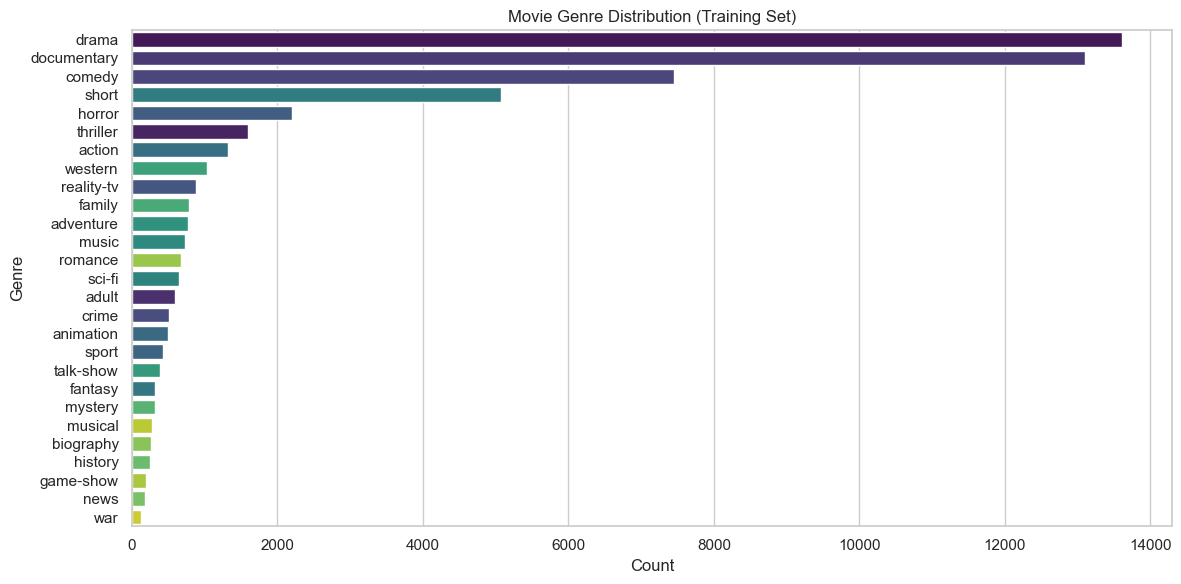

In [7]:
plt.figure(figsize=(12, 6))
order = df_train["genre"].value_counts().index
sns.countplot(y="genre", data=df_train, order=order, hue="genre", palette="viridis", legend=False)
plt.xlabel("Count")
plt.ylabel("Genre")
plt.title("Movie Genre Distribution (Training Set)")
plt.tight_layout()
plt.show()

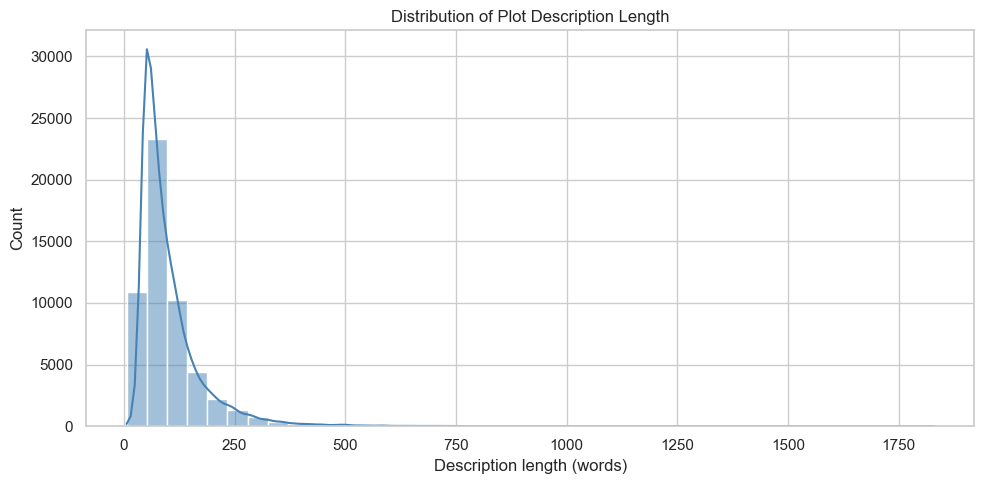

count    54214.000000
mean       101.907386
std         76.579192
min          6.000000
25%         55.000000
50%         79.000000
75%        121.000000
max       1829.000000
Name: desc_length, dtype: float64


In [8]:
df_train["desc_length"] = df_train["description"].str.split().str.len()

plt.figure(figsize=(10, 5))
sns.histplot(df_train["desc_length"], bins=40, kde=True, color="steelblue")
plt.xlabel("Description length (words)")
plt.title("Distribution of Plot Description Length")
plt.tight_layout()
plt.show()

print(df_train["desc_length"].describe())

In [9]:
def clean_text(text: str) -> str:
    """Lowercase, remove non-alphabetic characters, collapse whitespace."""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


df_train["clean_description"] = df_train["description"].apply(clean_text)
df_test["clean_description"] = df_test["description"].apply(clean_text)

df_train[["description", "clean_description"]].head()

,description,clean_description
0,Listening in to a conversation between his doc...,listening in to a conversation between his doc...
1,A brother and sister with a past incestuous re...,a brother and sister with a past incestuous re...
2,As the bus empties the students for their fiel...,as the bus empties the students for their fiel...
3,To help their unemployed father make ends meet...,to help their unemployed father make ends meet...
4,The film's title refers not only to the un-rec...,the film s title refers not only to the un rec...


In [10]:
label_encoder = LabelEncoder()
df_train["genre_encoded"] = label_encoder.fit_transform(df_train["genre"])

genre_mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
genre_mapping

{'action': 0,
 'adult': 1,
 'adventure': 2,
 'animation': 3,
 'biography': 4,
 'comedy': 5,
 'crime': 6,
 'documentary': 7,
 'drama': 8,
 'family': 9,
 'fantasy': 10,
 'game-show': 11,
 'history': 12,
 'horror': 13,
 'music': 14,
 'musical': 15,
 'mystery': 16,
 'news': 17,
 'reality-tv': 18,
 'romance': 19,
 'sci-fi': 20,
 'short': 21,
 'sport': 22,
 'talk-show': 23,
 'thriller': 24,
 'war': 25,
 'western': 26}

In [12]:
X_train_full, X_val, y_train_full, y_val = train_test_split(
    df_train["clean_description"],
    df_train["genre_encoded"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_train["genre_encoded"],
)

print("Train:", X_train_full.shape, " Val:", X_val.shape)

Train: (43371,)  Val: (10843,)


In [13]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=20000,
    min_df=2,
)

X_train_tfidf = vectorizer.fit_transform(X_train_full)
X_val_tfidf = vectorizer.transform(X_val)

print("TF-IDF train matrix shape:", X_train_tfidf.shape)

TF-IDF train matrix shape: (43371, 20000)


In [14]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
}

results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train_full)
    preds = model.predict(X_val_tfidf)
    acc = accuracy_score(y_val, preds)
    f1_macro = f1_score(y_val, preds, average="macro")
    results[name] = {"accuracy": acc, "f1_macro": f1_macro, "predictions": preds}
    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1 (macro): {f1_macro:.4f}")
    print(classification_report(y_val, preds, target_names=label_encoder.classes_, zero_division=0))
    print()

--- Naive Bayes ---
Accuracy : 0.5000
F1 (macro): 0.0997
              precision    recall  f1-score   support

      action       1.00      0.02      0.03       263
       adult       0.50      0.01      0.02       118
   adventure       0.67      0.03      0.05       155
   animation       0.00      0.00      0.00       100
   biography       0.00      0.00      0.00        53
      comedy       0.54      0.37      0.44      1490
       crime       0.00      0.00      0.00       101
 documentary       0.55      0.91      0.69      2619
       drama       0.44      0.84      0.57      2723
      family       0.00      0.00      0.00       157
     fantasy       0.00      0.00      0.00        65
   game-show       0.00      0.00      0.00        39
     history       0.00      0.00      0.00        49
      horror       0.85      0.15      0.25       441
       music       1.00      0.01      0.03       146
     musical       0.00      0.00      0.00        55
     mystery       0.00 

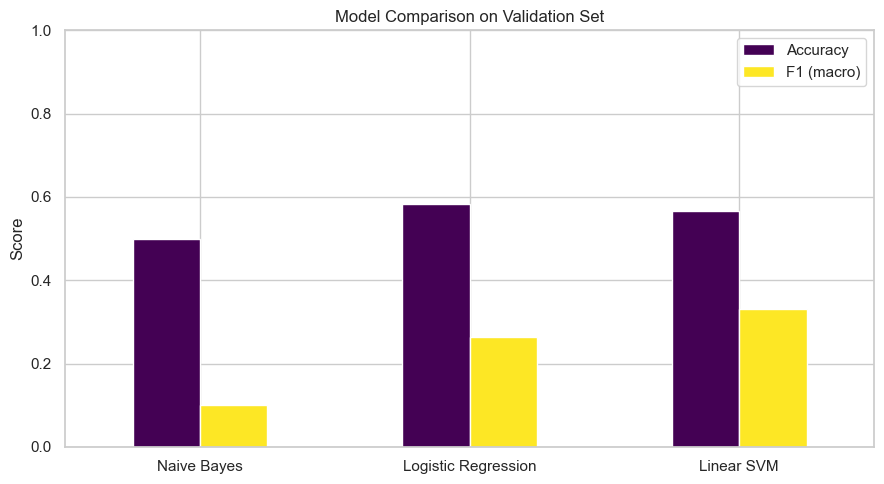

,Accuracy,F1 (macro)
Naive Bayes,0.500046,0.099715
Logistic Regression,0.583141,0.264547
Linear SVM,0.567094,0.331037


In [15]:
results_df = pd.DataFrame({
    name: {"Accuracy": r["accuracy"], "F1 (macro)": r["f1_macro"]}
    for name, r in results.items()
}).T

results_df.plot(kind="bar", figsize=(9, 5), rot=0, colormap="viridis")
plt.title("Model Comparison on Validation Set")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

results_df

Best model: Linear SVM


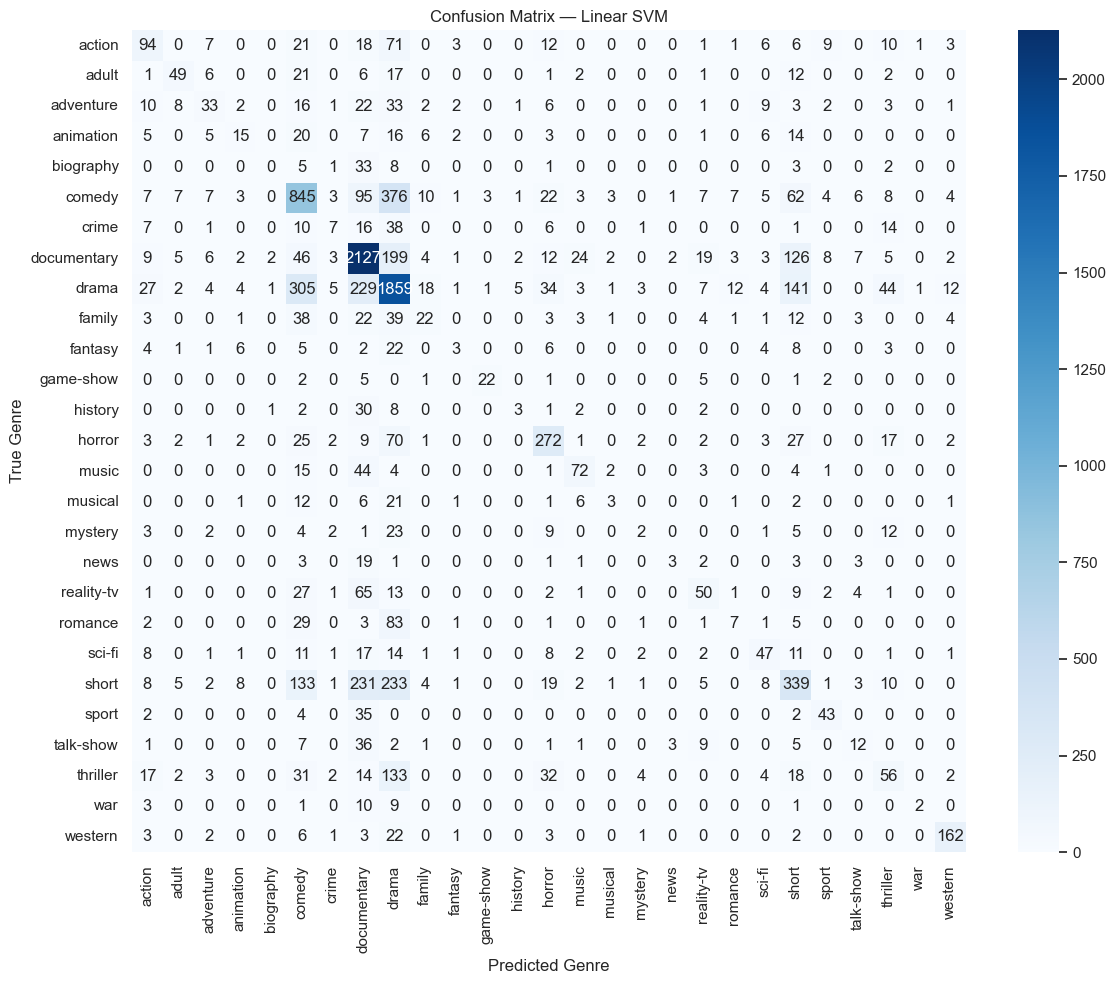

In [16]:
best_model_name = results_df["F1 (macro)"].idxmax()
print("Best model:", best_model_name)

best_preds = results[best_model_name]["predictions"]
cm = confusion_matrix(y_val, best_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
plt.xlabel("Predicted Genre")
plt.ylabel("True Genre")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
best_model_class = type(models[best_model_name])
final_model = best_model_class(**models[best_model_name].get_params())

final_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=20000,
    min_df=2,
)

X_full_tfidf = final_vectorizer.fit_transform(df_train["clean_description"])
y_full = df_train["genre_encoded"]

final_model.fit(X_full_tfidf, y_full)

X_test_tfidf = final_vectorizer.transform(df_test["clean_description"])
test_predictions = final_model.predict(X_test_tfidf)

df_test["predicted_genre"] = label_encoder.inverse_transform(test_predictions)
df_test[["id", "title", "predicted_genre"]].head(10)

,id,title,predicted_genre
0,1,Edgar's Lunch (1998),drama
1,2,La guerra de papá (1977),drama
2,3,Off the Beaten Track (2010),documentary
3,4,Meu Amigo Hindu (2015),drama
4,5,Er nu zhai (1955),drama
5,6,Riddle Room (2016),drama
6,7,L'amica (1969),drama
7,8,Ina Mina Dika (1989),comedy
8,9,Equinox Special: Britain's Tornados (2005),documentary
9,10,Press (2011),documentary


In [18]:
os.makedirs("output", exist_ok=True)

df_test[["id", "title", "predicted_genre"]].to_csv(
    "output/test_predictions.csv", index=False
)

joblib.dump(final_model, "output/genre_classifier_model.joblib")
joblib.dump(final_vectorizer, "output/tfidf_vectorizer.joblib")
joblib.dump(label_encoder, "output/label_encoder.joblib")

print("Saved: output/test_predictions.csv")
print("Saved: output/genre_classifier_model.joblib")
print("Saved: output/tfidf_vectorizer.joblib")
print("Saved: output/label_encoder.joblib")

Saved: output/test_predictions.csv
Saved: output/genre_classifier_model.joblib
Saved: output/tfidf_vectorizer.joblib
Saved: output/label_encoder.joblib
